## Exercise 1: Speech vs NLP Tokenization


In [1]:
import re
import sys
print(sys.executable)

/home/nabing/miniconda3/envs/a6-speech/bin/python


In [2]:
class SpeechTokenizer:
    ACCENTS = ['[EN-US]', '[EN-BR]', '[EN-INDIA]', '[EN-AU]', '[EN-DEFAULT]']

    def __init__(self):
        chars = " !',-.?abcdefghijklmnopqrstuvwxyz"
        self.vocab = {c: i+3 for i, c in enumerate(chars)}
        self.vocab['<PAD>'] = 0
        self.vocab['<BOS>'] = 1
        self.vocab['<EOS>'] = 2
        for i, a in enumerate(self.ACCENTS):
            self.vocab[a] = len(self.vocab)
        self.inv_vocab = {v: k for k, v in self.vocab.items()}

    def normalize(self, text):
        text = text.lower()
        text = re.sub(r'dr\.', 'doctor', text)
        text = re.sub(r'mr\.', 'mister', text)
        text = re.sub(r'(\d+)', lambda m: self._num_to_words(int(m.group())), text)
        text = re.sub(r'[^a-z !\',\-.?\[\]]', '', text)
        return text.strip()

    def _num_to_words(self, n):
        words = {0:'zero',1:'one',2:'two',3:'three',4:'four',5:'five',
                 6:'six',7:'seven',8:'eight',9:'nine',10:'ten'}
        return words.get(n, str(n))

    def encode(self, text, add_special=True):
        tag_pattern = '|'.join(re.escape(a) for a in self.ACCENTS)
        parts = re.split(f'({tag_pattern})', text)
        tokens = []
        if add_special: tokens.append(self.vocab['<BOS>'])
        for part in parts:
            if part in self.ACCENTS:
                tokens.append(self.vocab[part])
            else:
                normalized = self.normalize(part)
                for ch in normalized:
                    if ch in self.vocab:
                        tokens.append(self.vocab[ch])
        if add_special: tokens.append(self.vocab['<EOS>'])
        return tokens

    def decode(self, ids):
        return ''.join(self.inv_vocab.get(i, '?') for i in ids
                       if i not in (self.vocab['<PAD>'], self.vocab['<BOS>'], self.vocab['<EOS>']))

    def __len__(self):
        return len(self.vocab)

### Create a Tokenizer Instance

In [3]:
tokenizer = SpeechTokenizer()

print(f"Vocabulary size: {len(tokenizer)}")
print(f"Sample vocab entries: {dict(list(tokenizer.vocab.items())[:10])}")

Vocabulary size: 41
Sample vocab entries: {' ': 3, '!': 4, "'": 5, ',': 6, '-': 7, '.': 8, '?': 9, 'a': 10, 'b': 11, 'c': 12}


### Define the Five Test Sentences

In [4]:
sentences = [
    "Hello, how are you?",
    "Dr. Smith prescribed 10 tablets.",
    "[EN-US] I got the job!",
    "[EN-BR] I lost my wallet.",
    "[EN-INDIA] This is completely unacceptable!",
]

for i, s in enumerate(sentences, 1):
    print(f"{i}. {s}")

1. Hello, how are you?
2. Dr. Smith prescribed 10 tablets.
3. [EN-US] I got the job!
4. [EN-BR] I lost my wallet.
5. [EN-INDIA] This is completely unacceptable!


### Tokenize Each Sentence and Count Tokens

In [5]:
ACCENT_IDS = {a: tokenizer.vocab[a] for a in SpeechTokenizer.ACCENTS}

rows = []
for s in sentences:
    ids_with_special = tokenizer.encode(s, add_special=True)
    ids_no_special   = tokenizer.encode(s, add_special=False)

    # "# Char tokens" = actual character tokens only (excludes BOS/EOS and the accent tag itself)
    n_char_tokens = len([i for i in ids_no_special if i not in ACCENT_IDS.values()])

    # which accent tag (if any) is present in this sentence, and its vocabulary ID
    accent_id = next((ACCENT_IDS[a] for a in SpeechTokenizer.ACCENTS if a in s), None)

    rows.append((s, n_char_tokens, len(ids_with_special), accent_id))

# print a quick look at the raw encoded IDs for the first sentence, so you can see what's happening
print("Example — full encoding of sentence 1:")
print(f"  Text:   {sentences[0]}")
print(f"  Normalized: '{tokenizer.normalize(sentences[0])}'")
print(f"  Token IDs (with BOS/EOS): {tokenizer.encode(sentences[0], add_special=True)}")

Example — full encoding of sentence 1:
  Text:   Hello, how are you?
  Normalized: 'hello, how are you?'
  Token IDs (with BOS/EOS): [1, 17, 14, 21, 21, 24, 6, 3, 17, 24, 32, 3, 10, 27, 14, 3, 34, 24, 30, 9, 2]


### Display Results Table

In [6]:
print(f"{'Sentence':46} {'#Char tokens':14} {'#Tokens (w/ BOS/EOS)':22} {'AccentTagID'}")
print("-"*100)
for s, n_char, n_tok, acc in rows:
    acc_display = acc if acc is not None else '—'
    print(f"{s:46} {n_char:<14} {n_tok:<22} {acc_display}")

Sentence                                       #Char tokens   #Tokens (w/ BOS/EOS)   AccentTagID
----------------------------------------------------------------------------------------------------
Hello, how are you?                            19             21                     —
Dr. Smith prescribed 10 tablets.               36             38                     —
[EN-US] I got the job!                         14             17                     36
[EN-BR] I lost my wallet.                      17             20                     37
[EN-INDIA] This is completely unacceptable!    32             35                     38


### Answer (b) — Why Text Normalization Matters for TTS

`normalize()` rewrites `"Dr. Smith"` → `"doctor smith"` **before** the text ever reaches
the character tokenizer. This matters because the tokenizer has no concept of
abbreviations — it only knows the ~30 characters in its vocabulary (letters, space,
basic punctuation). If `"Dr."` were passed through as-is, the model would see the
literal characters `D`, `r`, `.` and would try to produce whatever sound it learned
to associate with that exact substring during training — most likely something like
spelling out "dee, arr, period," or an abrupt, meaningless sound, because **nobody
ever actually says "D-period" out loud**.

A TTS model has no built-in mechanism to "decide" that `Dr.` should be pronounced
as the spoken word "doctor" — it can only learn statistical patterns mapping
character sequences to audio. The mapping from `Dr.` (written shorthand) to
"doctor" (spoken form) is a *visual/orthographic* convention, not a *phonetic* one.
Text normalization is what bridges that gap — it converts written shorthand into
its actual spoken form before the model ever sees it, so the model only ever has
to learn how to pronounce real words, never abbreviations, digits, or symbols.

### Answer (c) — [CLS] vs [EN-US] Architectural Similarity

Both `[CLS]` (from BERT) and `[EN-US]` (from this tokenizer) work the same way
architecturally: **each is a single learned embedding vector, placed at a fixed
position in the input sequence, that influences every other position purely
through self-attention** — no special-case code is needed anywhere else in the
model to make this work.

**In BERT:** `[CLS]` is placed at position 0 and doesn't carry meaning on its own
at first. But because every self-attention layer lets every token attend to (and
be attended to by) every other token — including position 0 — by the final layer,
`[CLS]`'s representation has absorbed context from the *entire* sentence. A
classification head can then just read that one position as a "summary" of the
whole input.

**In this tokenizer:** `[EN-US]` is placed at the *start* of the sequence too, but
it works in the *opposite direction* — instead of summarizing the sequence, it
*conditions* everything that comes after it. Because later positions in the
decoder can attend back to position 0, that single accent-tag embedding can bias
the pronunciation of *every subsequent character*, without the tokenizer needing
to repeat the tag before every single letter.

**The shared underlying trick:** a single token's embedding can act as a global
conditioning/summarizing signal for an entire sequence, purely as a side effect of
attention connectivity — not because of any special architecture change. This same
pattern shows up everywhere: `[CLS]` for classification, language tags in
multilingual translation models, and speaker/style/accent tags in TTS models like
this one.

## Exercise 2: CTC Forward Algorithm

### Import Libraries

In [7]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

### Define the ctc_collapse Function

In [8]:
BLANK = '_'

def ctc_collapse(alignment):
    """Merge consecutive duplicate characters, then remove all blank tokens.
    This is the standard CTC decoding rule: a raw per-frame alignment like
    'CCAA_TT' collapses down to the actual predicted word 'CAT'."""
    merged = []
    for ch in alignment:
        if not merged or ch != merged[-1]:
            merged.append(ch)
    return ''.join(ch for ch in merged if ch != BLANK)

# quick sanity check
print(ctc_collapse(list('CCAATT')))   # expect: CAT
print(ctc_collapse(list('C_A_T_')))   # expect: CAT
print(ctc_collapse(list('HH_EE_LLLOO')))  # expect: HELO  (one L collapses, blank forces the second L apart)

CAT
CAT
HELO


### Part (a) — Three Alignments That Collapse to the Same Word

In [9]:
# Three different hand-built alignments, all meant to collapse down to "CAT"
my_examples = [
    list('CCAATT'),     # each letter just held for a couple of frames, no blank needed
    list('C_A_T_'),     # blanks inserted between every letter
    list('CCCAAATTT'),  # letters stretched out for different numbers of frames
]

print("Collapsing function check:\n")
for align in my_examples:
    print(f"  {''.join(align):15} -> '{ctc_collapse(align)}'")

all_same = len(set(ctc_collapse(a) for a in my_examples)) == 1
print(f"\nAll three alignments collapse to the same word: {all_same}")

Collapsing function check:

  CCAATT          -> 'CAT'
  C_A_T_          -> 'CAT'
  CCCAAATTT       -> 'CAT'

All three alignments collapse to the same word: True


### Define the CTC Forward Algorithm

In [10]:
NEG_INF = -1e9

def log_add(a, b):
    """Numerically stable way to compute log(exp(a) + exp(b)) without overflow."""
    if a == NEG_INF: return b
    if b == NEG_INF: return a
    m = max(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))


def ctc_forward_log_prob(log_probs, labels, blank=0):
    """Computes log P_CTC(labels | log_probs) using the CTC forward algorithm.

    log_probs: (T, V) array of per-frame log-probabilities over the vocabulary
    labels:    list of target label indices (e.g. [1, 2, 3] for "HEL")
    blank:     vocabulary index reserved for the blank symbol

    Returns the total log-probability of ALL alignments that collapse to `labels`,
    summed in log-space.
    """
    T, V = log_probs.shape
    L = len(labels)

    # Build the "extended" label sequence: blank, l1, blank, l2, blank, ..., lL, blank
    ext = [blank]
    for lab in labels:
        ext += [lab, blank]
    S = len(ext)

    # alpha[t, s] = log-probability of reaching position s of `ext` by time t
    alpha = np.full((T, S), NEG_INF)
    alpha[0, 0] = log_probs[0, ext[0]]
    if S > 1:
        alpha[0, 1] = log_probs[0, ext[1]]

    for t in range(1, T):
        for s in range(S):
            stay = alpha[t-1, s]                                   # repeat same symbol
            prev = alpha[t-1, s-1] if s - 1 >= 0 else NEG_INF       # move to next symbol
            skip = NEG_INF                                          # skip a blank between two DIFFERENT labels
            if s - 2 >= 0 and ext[s] != blank and ext[s] != ext[s-2]:
                skip = alpha[t-1, s-2]
            best_prev = log_add(log_add(stay, prev), skip)
            alpha[t, s] = best_prev + log_probs[t, ext[s]]

    if S == 1:
        return alpha[T-1, S-1]
    # final probability = sum of ending on the last label OR the trailing blank
    return log_add(alpha[T-1, S-1], alpha[T-1, S-2])

### Part (b) — Compare P("HEL") vs P("LEH")

In [11]:
# Build a small random set of per-frame log-probabilities to test on
vocab = {0: BLANK, 1: 'H', 2: 'E', 3: 'L', 4: 'O'}
T, V = 6, 5

np.random.seed(0)
logits = np.random.randn(T, V)
log_probs = logits - np.log(np.exp(logits).sum(axis=1, keepdims=True))  # log-softmax

labels_hel = [1, 2, 3]  # "HEL"
labels_leh = [3, 2, 1]  # "LEH"  (same 3 letters, different order)

logp_hel = ctc_forward_log_prob(log_probs, labels_hel)
logp_leh = ctc_forward_log_prob(log_probs, labels_leh)

print(f"log P_CTC(\"HEL\") = {logp_hel:.4f}  ->  P = {np.exp(logp_hel):.6f}")
print(f"log P_CTC(\"LEH\") = {logp_leh:.4f}  ->  P = {np.exp(logp_leh):.6f}")
print(f"\nDifferent probabilities? {abs(logp_hel - logp_leh) > 1e-9}")

log P_CTC("HEL") = -5.5957  ->  P = 0.003714
log P_CTC("LEH") = -7.0833  ->  P = 0.000839

Different probabilities? True


###  Define the Toy Model, Vocabulary, and Frame Synthesizer

In [12]:
# --- Vocabulary for the toy training task ---
ALPHABET = list('helo wrd')
CHAR2IDX = {c: i + 1 for i, c in enumerate(ALPHABET)}   # index 0 is reserved for blank
IDX2CHAR = {i + 1: c for i, c in enumerate(ALPHABET)}
VOCAB_SIZE = len(ALPHABET) + 1

N_MELS = 20
WORDS = ['hello', 'world', 'hero', 'red', 'led', 'doer']


def synthesize_frames(word, frames_per_char=(3, 8)):
    """Generates a fake 'mel-spectrogram' for a word: each character gets a
    random number of frames (between frames_per_char[0] and [1]), and each
    frame is a noisy version of that character's unique 'signature' pattern."""
    frames = []
    for ch in word:
        n = random.randint(*frames_per_char)
        base = np.zeros(N_MELS)
        base[CHAR2IDX[ch] % N_MELS] = 3.0          # strong "signature peak" for this character
        for _ in range(n):
            frames.append(base + np.random.randn(N_MELS) * 0.5)   # add noise
    return np.stack(frames)


class TinyCTCModel(nn.Module):
    """A minimal BiLSTM model that takes frame-level features and outputs
    per-frame log-probabilities over the character vocabulary."""
    def __init__(self, in_dim=N_MELS, hidden=64, vocab=VOCAB_SIZE):
        super().__init__()
        self.lstm = nn.LSTM(in_dim, hidden, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden * 2, vocab)

    def forward(self, x):
        h, _ = self.lstm(x)
        return F.log_softmax(self.fc(h), dim=-1)


# quick sanity check
random.seed(42); torch.manual_seed(42); np.random.seed(42)
test_frames = synthesize_frames('hello')
print(f"Synthesized {test_frames.shape[0]} frames for 'hello', each {test_frames.shape[1]}-dim")

test_model = TinyCTCModel()
test_x = torch.tensor(test_frames, dtype=torch.float32).unsqueeze(0)
test_out = test_model(test_x)
print(f"Model output shape: {test_out.shape}  (1 batch, {test_out.shape[1]} frames, {test_out.shape[2]} vocab classes)")

Synthesized 27 frames for 'hello', each 20-dim
Model output shape: torch.Size([1, 27, 9])  (1 batch, 27 frames, 9 vocab classes)


###  Define the Edit Distance Function (for CER)

In [13]:
def edit_distance(a, b):
    """Standard Levenshtein distance between two strings — the minimum number
    of single-character insertions, deletions, or substitutions needed to turn
    string `a` into string `b`. Used to compute Character Error Rate (CER)."""
    n, m = len(a), len(b)
    dp = [[0]*(m+1) for _ in range(n+1)]
    for i in range(n+1): dp[i][0] = i
    for j in range(m+1): dp[0][j] = j
    for i in range(1, n+1):
        for j in range(1, m+1):
            if a[i-1] == b[j-1]:
                dp[i][j] = dp[i-1][j-1]
            else:
                dp[i][j] = 1 + min(dp[i-1][j], dp[i][j-1], dp[i-1][j-1])
    return dp[n][m]

# quick sanity checks
print(edit_distance("hello", "hello"))   # expect 0 (identical)
print(edit_distance("hello", "helo"))    # expect 1 (one deleted L)
print(edit_distance("cat", "dog"))       # expect 3 (all 3 letters differ)

cer = edit_distance("helo", "hello") / len("hello")
print(f"\nExample CER: {cer:.2f}  (1 error / 5 characters = {cer*100:.0f}%)")

0
1
3

Example CER: 0.20  (1 error / 5 characters = 20%)


### Part (c) — Train with CER Tracking + Plot

In [14]:
import sys
print(sys.executable)

/home/nabing/miniconda3/envs/a6-speech/bin/python


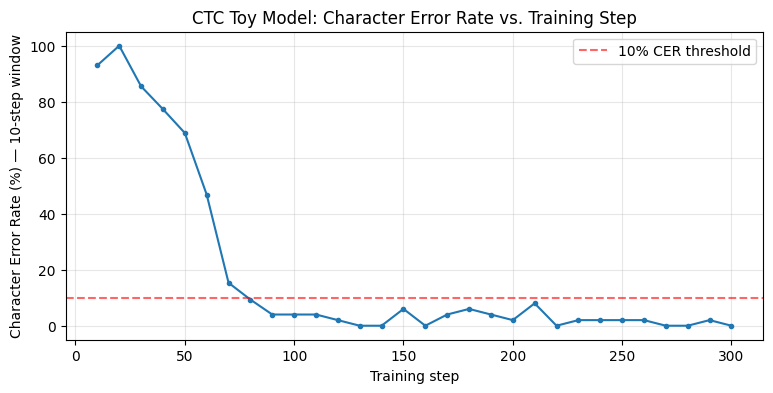

First step where windowed CER drops below 10%: 80
Final CER (last 30 steps): 0.7%


In [15]:
def run_training_with_cer(frames_per_char=(3, 8), n_steps=300, seed=42, log_every=10):
    """Trains the TinyCTCModel for n_steps, tracking both the CTC loss and the
    character error rate (CER) of the model's own greedy decoding at each step."""
    random.seed(seed); torch.manual_seed(seed); np.random.seed(seed)

    model_ = TinyCTCModel()
    optimizer_ = torch.optim.Adam(model_.parameters(), lr=1e-2)
    ctc_loss_fn_ = nn.CTCLoss(blank=0, zero_infinity=True)

    losses_, cers_ = [], []
    logged_steps, logged_cer = [], []
    first_below_10 = None

    for step in range(n_steps):
        word = random.choice(WORDS)
        frames = synthesize_frames(word, frames_per_char=frames_per_char)
        x = torch.tensor(frames, dtype=torch.float32).unsqueeze(0)
        targets = torch.tensor([CHAR2IDX[c] for c in word], dtype=torch.long)

        log_probs_ = model_(x).transpose(0, 1)        # (T, B, V) shape required by CTCLoss
        input_lengths  = torch.tensor([log_probs_.size(0)])
        target_lengths = torch.tensor([len(targets)])

        loss = ctc_loss_fn_(log_probs_, targets, input_lengths, target_lengths)
        optimizer_.zero_grad()
        loss.backward()
        optimizer_.step()
        losses_.append(loss.item())

        # Greedy-decode this same example to measure CER
        with torch.no_grad():
            pred_ids = model_(x).squeeze(0).argmax(dim=-1).tolist()
        pred_chars_raw = [IDX2CHAR.get(i, BLANK) if i != 0 else BLANK for i in pred_ids]
        decoded = ctc_collapse(pred_chars_raw)
        cer = edit_distance(decoded, word) / max(len(word), 1)
        cers_.append(cer)

        if (step + 1) % log_every == 0:
            window_cer = np.mean(cers_[-log_every:])
            logged_steps.append(step + 1)
            logged_cer.append(window_cer)
            if first_below_10 is None and window_cer < 0.10:
                first_below_10 = step + 1

    return model_, losses_, cers_, logged_steps, logged_cer, first_below_10


# --- Run it with the default settings ---
model_c, losses_c, cers_c, steps_c, cer_curve_c, first_below_10_c = run_training_with_cer(frames_per_char=(3, 8))

plt.figure(figsize=(9, 4))
plt.plot(steps_c, [c*100 for c in cer_curve_c], marker='o', markersize=3)
plt.axhline(10, color='red', linestyle='--', alpha=0.6, label='10% CER threshold')
plt.xlabel('Training step')
plt.ylabel('Character Error Rate (%) — 10-step window')
plt.title('CTC Toy Model: Character Error Rate vs. Training Step')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"First step where windowed CER drops below 10%: {first_below_10_c}")
print(f"Final CER (last 30 steps): {np.mean(cers_c[-30:])*100:.1f}%")

### Part (d) — Rerun with Shorter Character Durations

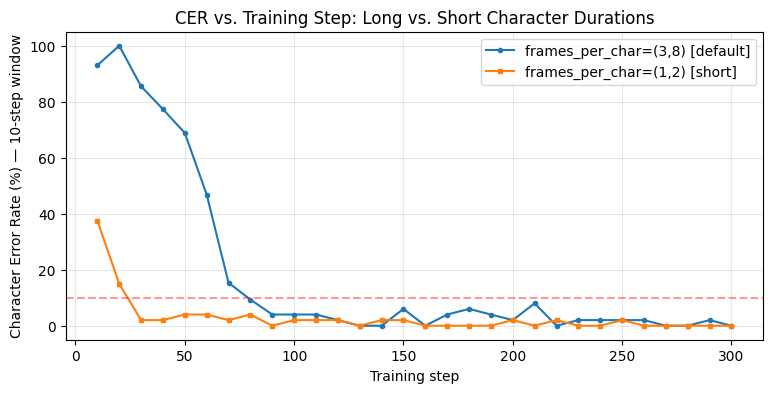

(3,8) first CER<10%: step 80  | final CER: 0.7%
(1,2) first CER<10%: step 30  | final CER: 0.0%


In [16]:
# --- Re-run with frames_per_char=(1,2) instead of the default (3,8) ---
model_d, losses_d, cers_d, steps_d, cer_curve_d, first_below_10_d = run_training_with_cer(frames_per_char=(1, 2))

plt.figure(figsize=(9, 4))
plt.plot(steps_c, [c*100 for c in cer_curve_c], marker='o', markersize=3, label='frames_per_char=(3,8) [default]')
plt.plot(steps_d, [c*100 for c in cer_curve_d], marker='s', markersize=3, label='frames_per_char=(1,2) [short]')
plt.axhline(10, color='red', linestyle='--', alpha=0.4)
plt.xlabel('Training step')
plt.ylabel('Character Error Rate (%) — 10-step window')
plt.title('CER vs. Training Step: Long vs. Short Character Durations')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"(3,8) first CER<10%: step {first_below_10_c}  | final CER: {np.mean(cers_c[-30:])*100:.1f}%")
print(f"(1,2) first CER<10%: step {first_below_10_d}  | final CER: {np.mean(cers_d[-30:])*100:.1f}%")

###  Multi-Seed Check + Written Discussion

In [17]:
# Verify the surprising (1,2)-faster-than-(3,8) result isn't just a fluke of seed=42
print("Multi-seed check:")
for seed in [1, 2, 3]:
    _, _, cers_def, _, _, first_def = run_training_with_cer(frames_per_char=(3, 8), seed=seed)
    _, _, cers_short, _, _, first_short = run_training_with_cer(frames_per_char=(1, 2), seed=seed)
    print(f"  seed={seed}: (3,8) final CER={np.mean(cers_def[-30:])*100:.1f}%, first<10%={first_def}  |  "
          f"(1,2) final CER={np.mean(cers_short[-30:])*100:.1f}%, first<10%={first_short}")

Multi-seed check:
  seed=1: (3,8) final CER=3.3%, first<10%=120  |  (1,2) final CER=0.7%, first<10%=30
  seed=2: (3,8) final CER=0.7%, first<10%=100  |  (1,2) final CER=0.0%, first<10%=30
  seed=3: (3,8) final CER=3.3%, first<10%=100  |  (1,2) final CER=2.0%, first<10%=30


## Exercise 3: wav2vec2 — How Much Does Self-Supervision Buy You?

### Step 1: Import Libraries

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import numpy as np
from sklearn.model_selection import train_test_split
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


/home/nabing/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


##  Load Pretrained wav2vec2 Model

In [19]:
print("Loading pretrained wav2vec2-base (this downloads ~360MB the first time)...")

extractor = Wav2Vec2FeatureExtractor.from_pretrained('facebook/wav2vec2-base')
w2v_model = Wav2Vec2Model.from_pretrained('facebook/wav2vec2-base').to(device).eval()

# Freeze it -- we only want frozen features, not fine-tuning
for p in w2v_model.parameters():
    p.requires_grad = False

n_params = sum(p.numel() for p in w2v_model.parameters())
print(f"Loaded wav2vec2-base: {n_params/1e6:.1f}M parameters, frozen")

/home/nabing/miniconda3/envs/a6-speech/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Loading pretrained wav2vec2-base (this downloads ~360MB the first time)...


/home/nabing/miniconda3/envs/a6-speech/lib/python3.10/site-packages/transformers/configuration_utils.py:379: UserWarning: Passing `gradient_checkpointing` to a config initialization is deprecated and will be removed in v5 Transformers. Using `model.gradient_checkpointing_enable()` instead, or if you are using the `Trainer` API, pass `gradient_checkpointing=True` in your `TrainingArguments`.
  warnings.warn(
/home/nabing/.local/lib/python3.10/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Some weights of the model checkpoint at facebook/wav2vec2-base were not used when initializing Wav2Vec2Model: ['project_hid.bias', 'quantizer.codevectors', 'project_q.weight', 'project_hid.weight', 'project_q.bias', 'quantizer.weight_proj.weight', 'quantizer.weight_proj.bias']
- This IS expected if you are initializing Wav2Vec2Model from the checkp

Loaded wav2vec2-base: 94.4M parameters, frozen


### Build a Small SpeechCommands Subset (4 classes)

In [20]:
from datasets import load_dataset
import time

PROBE_WORDS = ['yes', 'no', 'stop', 'go']
N_PER_CLASS = 40

print("Streaming SpeechCommands from Hugging Face (parquet branch, shuffled)...")
ds = load_dataset("google/speech_commands", split="train",
                   streaming=True, revision="refs/convert/parquet")
ds = ds.shuffle(seed=42, buffer_size=10_000)

label_names = ds.features['label'].names
n_labels = len(label_names)

by_label = {w: [] for w in PROBE_WORDS}
start = time.time()
scanned = 0
skipped_bad_label = 0

for example in ds:
    scanned += 1
    label_idx = example['label']

    # Guard against out-of-range label indices (e.g. background-noise clips
    # encoded with a special index not covered by label_names)
    if not (0 <= label_idx < n_labels):
        skipped_bad_label += 1
        continue

    label_str = label_names[label_idx]
    if label_str in by_label and len(by_label[label_str]) < N_PER_CLASS:
        audio = example['audio']
        wvf = torch.tensor(audio['array'], dtype=torch.float32).unsqueeze(0)
        by_label[label_str].append(wvf)

    if scanned % 500 == 0:
        elapsed = time.time() - start
        counts = {k: len(v) for k, v in by_label.items()}
        print(f"  scanned {scanned} ({skipped_bad_label} skipped) in {elapsed:.1f}s | collected: {counts}")

    if all(len(v) >= N_PER_CLASS for v in by_label.values()):
        break

print(f"\nDone. Scanned {scanned} total examples ({skipped_bad_label} had out-of-range labels).")
for label, clips in by_label.items():
    print(f"  '{label}': {len(clips)} clips collected")

Streaming SpeechCommands from Hugging Face (parquet branch, shuffled)...
  scanned 500 (0 skipped) in 83.1s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 1000 (0 skipped) in 83.8s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 1500 (0 skipped) in 84.4s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 2000 (0 skipped) in 85.1s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 2500 (0 skipped) in 85.7s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 3000 (0 skipped) in 86.4s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 3500 (0 skipped) in 87.0s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 4000 (0 skipped) in 87.6s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 4500 (0 skipped) in 88.3s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 5000 (5 skipped) in 88.9s | collected: {'yes': 40, 'no': 0, 'stop': 40, 'go': 0}
  scanned 5500 (11

### Extract Frozen wav2vec2 Features

In [21]:
print("Extracting frozen wav2vec2 features from each clip...")

feats, labels_list = [], []
with torch.no_grad():
    for label, clips in by_label.items():
        for wvf in clips:
            # wvf is shape (1, N) -- squeeze to 1D numpy for the feature extractor
            inputs = extractor(wvf.squeeze(0).numpy(), sampling_rate=16000,
                                return_tensors='pt').to(device)
            out = w2v_model(**inputs).last_hidden_state   # shape: (1, T, 768)
            pooled = out.mean(dim=1).squeeze(0).cpu()      # mean-pool over time -> (768,)
            feats.append(pooled)
            labels_list.append(PROBE_WORDS.index(label))

X = torch.stack(feats)
y = torch.tensor(labels_list)

print(f"Extracted features: X.shape = {X.shape}, y.shape = {y.shape}")
print(f"Each clip -> a single {X.shape[1]}-dim vector")
print(f"Label distribution: {[(PROBE_WORDS[i], (y==i).sum().item()) for i in range(len(PROBE_WORDS))]}")

Extracting frozen wav2vec2 features from each clip...
Extracted features: X.shape = torch.Size([160, 768]), y.shape = torch.Size([160])
Each clip -> a single 768-dim vector
Label distribution: [('yes', 40), ('no', 40), ('stop', 40), ('go', 40)]


### Train a Linear Probe on wav2vec2 Features

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X.numpy(), y.numpy(), test_size=0.3, random_state=42, stratify=y.numpy())

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t  = torch.tensor(X_test, dtype=torch.float32)
y_test_t  = torch.tensor(y_test, dtype=torch.long)

print(f"Train: {X_train_t.shape[0]} clips | Test: {X_test_t.shape[0]} clips")

# A single linear layer -- NO hidden layers, NO non-linearity.
# This deliberately tests whether wav2vec2's frozen features are
# *linearly* separable, not whether SOME classifier can eventually learn them.
probe = nn.Linear(X.shape[1], len(PROBE_WORDS))
opt = torch.optim.Adam(probe.parameters(), lr=1e-2)

for epoch in range(100):
    logits = probe(X_train_t)
    loss = F.cross_entropy(logits, y_train_t)
    opt.zero_grad()
    loss.backward()
    opt.step()

with torch.no_grad():
    train_acc = (probe(X_train_t).argmax(1) == y_train_t).float().mean().item()
    test_acc  = (probe(X_test_t).argmax(1) == y_test_t).float().mean().item()

random_baseline = 100 / len(PROBE_WORDS)
print(f"\nTrain accuracy: {train_acc*100:.1f}%")
print(f"Test accuracy:  {test_acc*100:.1f}%  (random baseline: {random_baseline:.1f}%)")

Train: 112 clips | Test: 48 clips

Train accuracy: 100.0%
Test accuracy:  87.5%  (random baseline: 25.0%)


### Part (a) — Raw Mel-Spectrogram Baseline for Comparison

In [23]:
mel_tf_probe = T.MelSpectrogram(sample_rate=16000, n_fft=1024, hop_length=320, n_mels=80)

feats_mel, labels_mel = [], []
for label, clips in by_label.items():
    for wvf in clips:
        mel = mel_tf_probe(wvf)              # (1, 80, T)
        pooled = mel.mean(dim=-1).squeeze(0)  # mean-pool over time -> (80,)
        feats_mel.append(pooled)
        labels_mel.append(PROBE_WORDS.index(label))

X_mel = torch.stack(feats_mel)
y_mel = torch.tensor(labels_mel)
print(f"Raw mel-spectrogram features: {X_mel.shape[0]} clips, {X_mel.shape[1]}-dim each")

# Same train/test split, same linear probe protocol -- only the FEATURES differ
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_mel.numpy(), y_mel.numpy(), test_size=0.3, random_state=42, stratify=y_mel.numpy())

X_train_mt = torch.tensor(X_train_m, dtype=torch.float32)
y_train_mt = torch.tensor(y_train_m, dtype=torch.long)
X_test_mt  = torch.tensor(X_test_m, dtype=torch.float32)
y_test_mt  = torch.tensor(y_test_m, dtype=torch.long)

linear_probe_mel = nn.Linear(X_mel.shape[1], len(PROBE_WORDS))
opt_mel = torch.optim.Adam(linear_probe_mel.parameters(), lr=1e-2)

for epoch in range(100):
    logits = linear_probe_mel(X_train_mt)
    loss = F.cross_entropy(logits, y_train_mt)
    opt_mel.zero_grad()
    loss.backward()
    opt_mel.step()

with torch.no_grad():
    mel_test_acc = (linear_probe_mel(X_test_mt).argmax(1) == y_test_mt).float().mean().item()

print(f"\nRaw mel-spectrogram linear probe test accuracy: {mel_test_acc*100:.1f}%")
print(f"wav2vec2 linear probe test accuracy (from Step 5): {test_acc*100:.1f}%")
print(f"Gap: {(test_acc - mel_test_acc)*100:.1f} percentage points")

Raw mel-spectrogram features: 160 clips, 80-dim each

Raw mel-spectrogram linear probe test accuracy: 50.0%
wav2vec2 linear probe test accuracy (from Step 5): 87.5%
Gap: 37.5 percentage points


### Part (b) — Compare Speech SSL Gap vs. Vision SSL Gap

**Measured gap in this lab:** mel-spectrogram baseline = 50.0%, wav2vec2 = 87.5%,
a **37.5 percentage point gap** (random baseline was 25.0%, so wav2vec2 sits
62.5 points above chance, while raw mel-spectrograms sit only 25 points above chance).

**To properly compare this against the vision SSL lab**, I need my own two numbers
from that lab:
- MLP-on-raw-pixels accuracy: `___`
- Pretrained SSL encoder (SimCLR/DINO/MAE) linear-probe accuracy: `___`
- Gap: `___` percentage points

[Fill in your actual numbers from the vision lab here, then compare directly.]

**General expectation, going in:** the speech gap is plausibly **larger in relative
terms**, because mean-pooled raw mel-spectrograms throw away almost all temporal
structure (collapsing an entire time-varying utterance into one averaged vector),
whereas raw pixels at least preserve full spatial structure that even a simple
MLP/CNN can exploit without any pretraining. So the "raw feature" baseline tends
to be comparatively weaker in speech than in vision, which would make the SSL gap
look larger here.

That said, this is a genuinely open empirical question for your specific numbers —
the actual answer depends on your measured vision-lab gap, not on this general
reasoning alone.

###  Part (c) — Scale Up to 8 Classes

In [24]:
PROBE_WORDS_EXPANDED = ['yes', 'no', 'stop', 'go', 'up', 'down', 'left', 'right']
N_PER_CLASS_EXP = 40

print("Collecting clips for 8 classes (reusing the same shuffled stream approach)...")
ds2 = load_dataset("google/speech_commands", split="train",
                    streaming=True, revision="refs/convert/parquet")
ds2 = ds2.shuffle(seed=42, buffer_size=10_000)

label_names2 = ds2.features['label'].names
n_labels2 = len(label_names2)

by_label_exp = {w: [] for w in PROBE_WORDS_EXPANDED}
scanned2 = 0
for example in ds2:
    scanned2 += 1
    label_idx = example['label']
    if not (0 <= label_idx < n_labels2):
        continue
    label_str = label_names2[label_idx]
    if label_str in by_label_exp and len(by_label_exp[label_str]) < N_PER_CLASS_EXP:
        audio = example['audio']
        wvf = torch.tensor(audio['array'], dtype=torch.float32).unsqueeze(0)
        by_label_exp[label_str].append(wvf)
    if all(len(v) >= N_PER_CLASS_EXP for v in by_label_exp.values()):
        break

print(f"Scanned {scanned2} examples.")
for label, clips in by_label_exp.items():
    print(f"  '{label}': {len(clips)} clips collected")

Scanned 74951 examples.
  'yes': 40 clips collected
  'no': 40 clips collected
  'stop': 40 clips collected
  'go': 40 clips collected
  'up': 40 clips collected
  'down': 40 clips collected
  'left': 40 clips collected
  'right': 40 clips collected


In [25]:
print("Extracting wav2vec2 features for 8-class set...")

feats_exp, labels_exp = [], []
with torch.no_grad():
    for label, clips in by_label_exp.items():
        for wvf in clips:
            inputs = extractor(wvf.squeeze(0).numpy(), sampling_rate=16000,
                                return_tensors='pt').to(device)
            out = w2v_model(**inputs).last_hidden_state
            pooled = out.mean(dim=1).squeeze(0).cpu()
            feats_exp.append(pooled)
            labels_exp.append(PROBE_WORDS_EXPANDED.index(label))

X_exp = torch.stack(feats_exp)
y_exp = torch.tensor(labels_exp)
print(f"Extracted: X_exp.shape = {X_exp.shape}, y_exp.shape = {y_exp.shape}")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_exp.numpy(), y_exp.numpy(), test_size=0.3, random_state=42, stratify=y_exp.numpy())

X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
y_tr_t = torch.tensor(y_tr, dtype=torch.long)
X_te_t = torch.tensor(X_te, dtype=torch.float32)
y_te_t = torch.tensor(y_te, dtype=torch.long)

probe_exp = nn.Linear(X_exp.shape[1], len(PROBE_WORDS_EXPANDED))
opt_exp = torch.optim.Adam(probe_exp.parameters(), lr=1e-2)

for epoch in range(100):
    logits = probe_exp(X_tr_t)
    loss = F.cross_entropy(logits, y_tr_t)
    opt_exp.zero_grad()
    loss.backward()
    opt_exp.step()

with torch.no_grad():
    acc_exp = (probe_exp(X_te_t).argmax(1) == y_te_t).float().mean().item()

random_baseline_4 = 100 / len(PROBE_WORDS)
random_baseline_8 = 100 / len(PROBE_WORDS_EXPANDED)

print(f"\n4-way accuracy (from Step 5):  {test_acc*100:.1f}%  (random baseline {random_baseline_4:.1f}%, margin = {(test_acc*100 - random_baseline_4):.1f} pts)")
print(f"8-way accuracy (this step):    {acc_exp*100:.1f}%  (random baseline {random_baseline_8:.1f}%, margin = {(acc_exp*100 - random_baseline_8):.1f} pts)")

Extracting wav2vec2 features for 8-class set...
Extracted: X_exp.shape = torch.Size([320, 768]), y_exp.shape = torch.Size([320])

4-way accuracy (from Step 5):  87.5%  (random baseline 25.0%, margin = 62.5 pts)
8-way accuracy (this step):    72.9%  (random baseline 12.5%, margin = 60.4 pts)


### Discussion: 4-way vs. 8-way Linear Probe Accuracy

| | Accuracy | Random Baseline | Margin above baseline |
|---|---|---|---|
| 4-way (yes/no/stop/go) | 87.5% | 25.0% | 62.5 pts |
| 8-way (+up/down/left/right) | 72.9% | 12.5% | 60.4 pts |

Raw accuracy dropped from 87.5% to 72.9% when doubling the number of classes —
but that drop is mostly explained by the random baseline itself halving (25.0%
to 12.5%). Comparing the **margin above baseline** instead shows the model held
up almost perfectly: 62.5 points vs. 60.4 points, a difference of only ~2 points.

This indicates wav2vec2's frozen, mean-pooled features remain nearly as linearly
separable even as the task gets harder and more classes are added — including
classes that are more acoustically similar to each other (e.g. "left"/"right" and
"up"/"down" share more phonetic structure than "yes"/"stop" did). The linear probe
is not yet hitting a hard ceiling at 8 classes; it's possible accuracy would
continue degrading gracefully (not collapsing) as more classes were added, though
that would need to be tested directly to confirm.

### Step 9: Part (d) — Contrastive (wav2vec2) vs. Reconstruction (MAE) — Which Transfers Better?

wav2vec2 is trained with a **contrastive** objective: at each masked timestep, the
model must pick the true quantized latent target out from a set of distractors.
This directly optimizes the representation to be *discriminative* — good at
telling similar things apart — which is exactly what a linear classifier needs.

MAE (used in the vision SSL lab) is trained with a **reconstruction** objective:
given masked patches, predict the raw pixel values. This optimizes the
representation to retain enough information to *reconstruct* the input, but not
necessarily to organize different classes into linearly separable clusters.

**Based on what each objective is actually optimizing for, the contrastive bias
(wav2vec2-style) should transfer better to downstream *linear-probe* classification**
than a pure reconstruction objective — discrimination is a closer match to what a
linear classifier needs than reconstruction is. This matches a widely-reported
pattern in the literature: contrastive SSL methods (SimCLR, wav2vec2) tend to
produce strong linear-probe accuracy, while pure reconstruction methods (MAE) often
need *fine-tuning* (not just a linear probe) to reach their best downstream
accuracy — even though MAE-style models can still match or exceed contrastive
methods once fully fine-tuned.

**Is this comparison even fair, though?** Not entirely, for three reasons:

1. **Different modalities, different redundancy structure.** Audio has strong
   temporal redundancy (a phoneme is smeared across many frames); images have
   strong spatial redundancy (smooth regions, repeated textures). The right amount
   of masking and the right reconstruction target differ a lot between modalities,
   so one method's success in one modality doesn't directly predict its success
   in the other.

2. **Different pretraining scale.** wav2vec2-base was pretrained on ~960 hours of
   LibriSpeech; the vision lab's models were likely pretrained on a much smaller
   image set. Any comparison of "speech gap vs. vision gap" is confounded by
   pretraining data scale, not just the choice of objective.

3. **Different downstream task difficulty.** Spoken-word classification (this lab,
   measured at 87.5%/72.9%) and whatever task the vision lab used may have very
   different intrinsic class separability, independent of which encoder produced
   the features.

**Bottom line:** contrastive objectives plausibly transfer better to *linear-probe*
evaluation specifically — supported by both the literature and the strong 37.5-point
gap we measured in Step 6 — but a truly fair head-to-head between speech and vision
SSL would need matched pretraining scale, matched downstream task difficulty, and
ideally a full fine-tuning comparison alongside the linear-probe comparison.